In [1]:
#import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera
from numpy import log
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller
from scipy.stats import t
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


In [2]:
empresa = 'MSFT'


In [3]:
#data=yf.download(empresa, period="5y" ,interval='1d', auto_adjust=False)
#data.head()

In [4]:
data=pd.read_csv('Microsoft.csv')
data.dropna(inplace=True)
data['Close']=pd.to_numeric(data['Close'], errors='coerce')
data.head()


,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-09-28,200.816360,209.440002,212.570007,208.059998,210.880005,32004900
1,2020-09-29,198.726135,207.259995,210.070007,206.809998,209.350006,24221900
2,2020-09-30,201.669754,210.330002,211.979996,206.539993,207.729996,33829100
3,2020-10-01,203.712067,212.460007,213.990005,211.320007,213.490005,27158400
4,2020-10-02,197.700226,206.190002,210.990005,205.539993,208.000000,33154800


In [5]:
data.index=pd.to_datetime(data.Date)

In [6]:
train = data['Close'].iloc[:int(len(data)*0.8)]  # 80% para entrenamiento
test = data['Close'].iloc[int(len(data)*0.8):]   # 20% para prueba
n_prueba=len(test)

<Axes: xlabel='Date'>

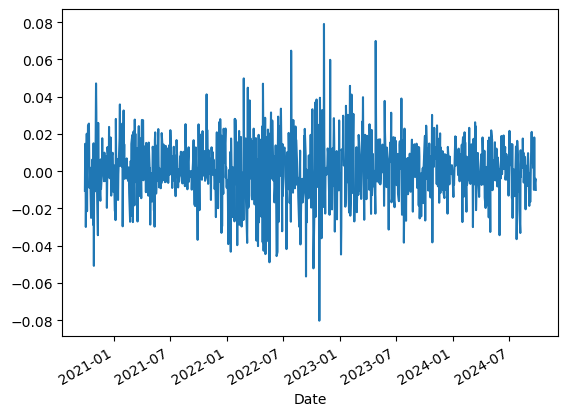

In [7]:
log= np.log(train/ train.shift(1)).dropna()
log.plot()

## Division de los datos

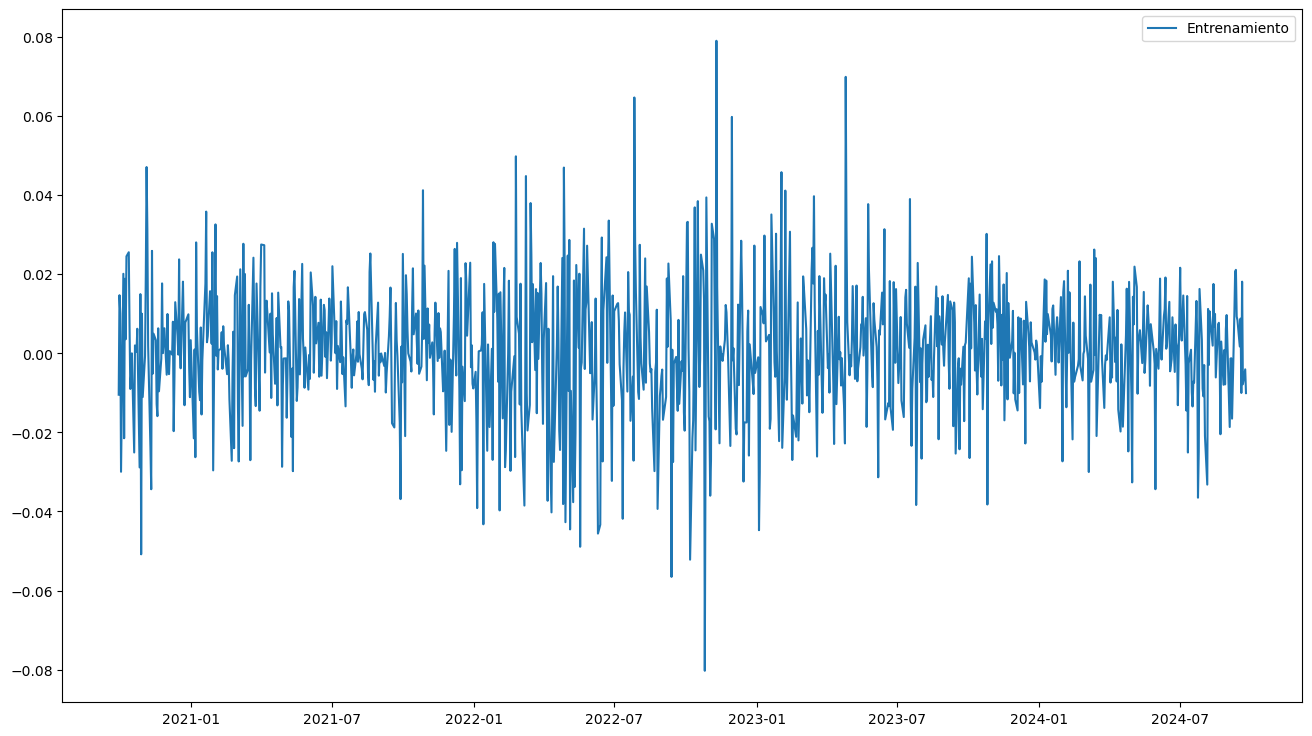

In [8]:
fig,ax=plt.subplots(figsize=(16,9))
ax.plot(log, label='Entrenamiento')
#ax.plot(test, label='Prueba')
plt.legend()
plt.show()

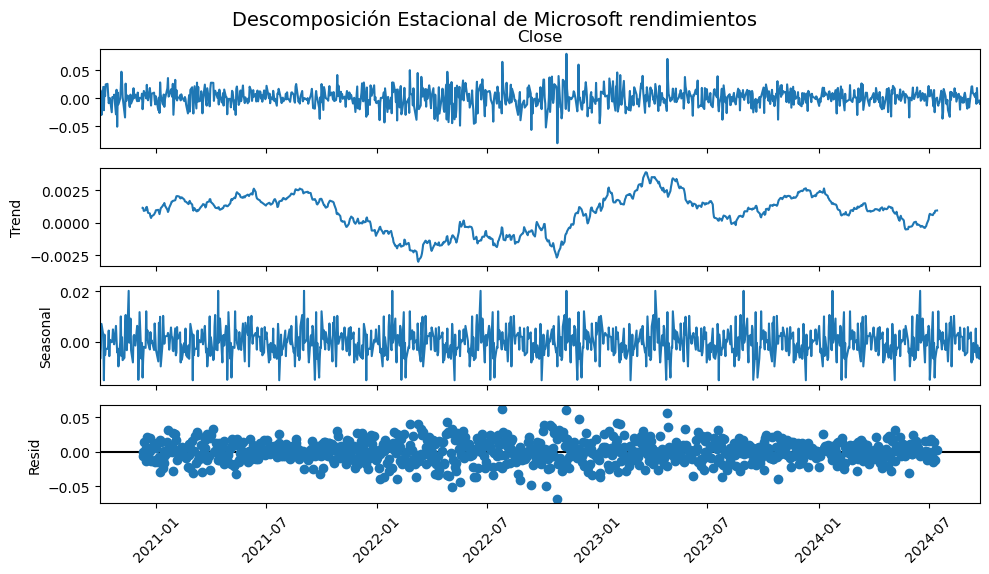

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

resultado = seasonal_decompose(log, model='additive', period=100)
fig = resultado.plot()
fig.suptitle('Descomposición Estacional de Microsoft rendimientos', fontsize=14, y=0.95)
fig.set_size_inches(10, 6)  # Ajustar tamaño
plt.xticks(rotation=45)# Rotar etiquetas
plt.tight_layout()          # Ajustar layout
plt.show()

## Aplicar el test de dickey-fuller para ver estacionalidad y encontrar el valor d

In [10]:
def test_dickey(series, column_name):
    print(f'Resultados de la prueba de Dickey-Fuller para columna: {column_name}')
    
    # Aplicar la prueba de Dickey-Fuller
    dftest = adfuller(series,regression='ct', maxlag=10, autolag='AIC')
    
    # Crear un DataFrame con los resultados
    dfoutput = pd.Series(dftest[0:4], 
                         index=['Estadístico de prueba', 'p-valor', 'N° de lags usados', 'N° de observaciones usadas'])
    
    for key, value in dftest[4].items():
        dfoutput[f'Valor crítico ({key})'] = value
    
    # Mostrar resultados
    print(dfoutput)
    
    # Evaluar estacionariedad
    print("\nConclusión:====>")
    if dftest[1] <= 0.05:
        print("Rechazamos la hipótesis nula: Los datos son estacionarios")
    else:
        print("No se puede rechazar la hipótesis nula: Los datos NO son estacionarios ")



In [11]:
test_dickey(log,"Close")

Resultados de la prueba de Dickey-Fuller para columna: Close
Estadístico de prueba          -20.233205
p-valor                          0.000000
N° de lags usados                2.000000
N° de observaciones usadas    1000.000000
Valor crítico (1%)              -3.967852
Valor crítico (5%)              -3.414889
Valor crítico (10%)             -3.129640
dtype: float64

Conclusión:====>
Rechazamos la hipótesis nula: Los datos son estacionarios


## Encontrar los valores de p y q

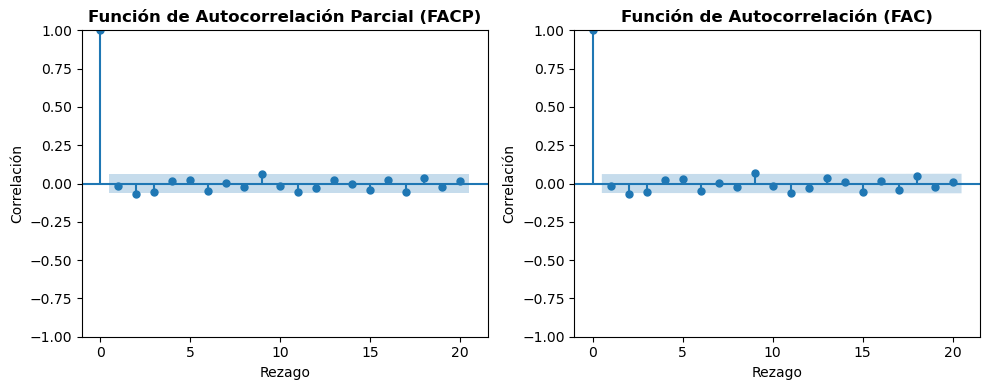

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_pacf(log, ax=ax[0], lags=20)
plot_acf(log, ax=ax[1], lags=20)
ax[0].set_title('Función de Autocorrelación Parcial (FACP)', fontsize=12, fontweight='bold')
ax[1].set_title('Función de Autocorrelación (FAC)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Correlación')
ax[1].set_ylabel('Correlación')
ax[0].set_xlabel('Rezago')
ax[1].set_xlabel('Rezago')

plt.tight_layout()
plt.show()

Generemos el modelo

In [13]:
%%time
modelo=SARIMAX(log, order=(3,0,3), seasonal_order=(1,1,1,100))
modelo_fit=modelo.fit()
print(modelo_fit.summary())

/opt/ohpc/pub/BUILDS/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/ohpc/pub/BUILDS/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.22498D+00    |proj g|=  1.18262D+01

At iterate    5    f= -2.25136D+00    |proj g|=  6.87515D-02

At iterate   10    f= -2.25229D+00    |proj g|=  2.79955D+00

At iterate   15    f= -2.26002D+00    |proj g|=  1.34830D-01

At iterate   20    f= -2.26042D+00    |proj g|=  1.12388D+00

At iterate   25    f= -2.27959D+00    |proj g|=  4.65629D+00

At iterate   30    f= -2.28449D+00    |proj g|=  5.11793D-01

At iterate   35    f= -2.29172D+00    |proj g|=  2.94034D-01

At iterate   40    f= -2.29948D+00    |proj g|=  9.92610D-01

At iterate   45    f= -2.30320D+00    |proj g|=  2.16430D-02

At iterate   50    f= -2.30524D+00    |proj g|=  4.00389D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/opt/ohpc/pub/BUILDS/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                       SARIMAX Results                                       
Dep. Variable:                                 Close   No. Observations:                 1003
Model:             SARIMAX(3, 0, 3)x(1, 1, [1], 100)   Log Likelihood                2312.155
Date:                               Thu, 19 Mar 2026   AIC                          -4606.310
Time:                                       18:19:37   BIC                          -4563.059
Sample:                                            0   HQIC                         -4589.790
                                              - 1003                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5317      0.339     -1.569      0.117      -1.196       0.132
ar.L2      

In [14]:
# Guardar solo los parámetros en un archivo CSV
parametros = {
    'parametro': modelo_fit.params.index,
    'valor': modelo_fit.params.values,
    'error_std': modelo_fit.bse.values,  # Errores estándar
    'p_valor': modelo_fit.pvalues.values
}

df_parametros = pd.DataFrame(parametros)
df_parametros.to_csv('parametros_microsoft.csv', index=False)

In [16]:
ultimo_precio

429.1700134277344

In [15]:
# 1. Predicciones de rendimientos
pred_rendimientos = modelo_fit.forecast(steps=n_prueba)

# 2. Último precio conocido (ANTES del periodo de prueba)
ultimo_precio = train.iloc[-1]  # Ajusta según tus datos

# 3. Conversión directa y segura
precios_predichos = [ultimo_precio]
for i, rendimiento in enumerate(pred_rendimientos):
    nuevo_precio = precios_predichos[-1] * np.exp(rendimiento)
    precios_predichos.append(nuevo_precio)

# Los precios predichos son desde el elemento 1 en adelante
pred = precios_predichos[1:]

print(f"Predicciones convertidas: {len(pred)} puntos")
print(f"De {pred[0]:.2f} a {pred[-1]:.2f}")

/opt/ohpc/pub/BUILDS/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/ohpc/pub/BUILDS/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Predicciones convertidas: 252 puntos
De 431.68 a 511.40


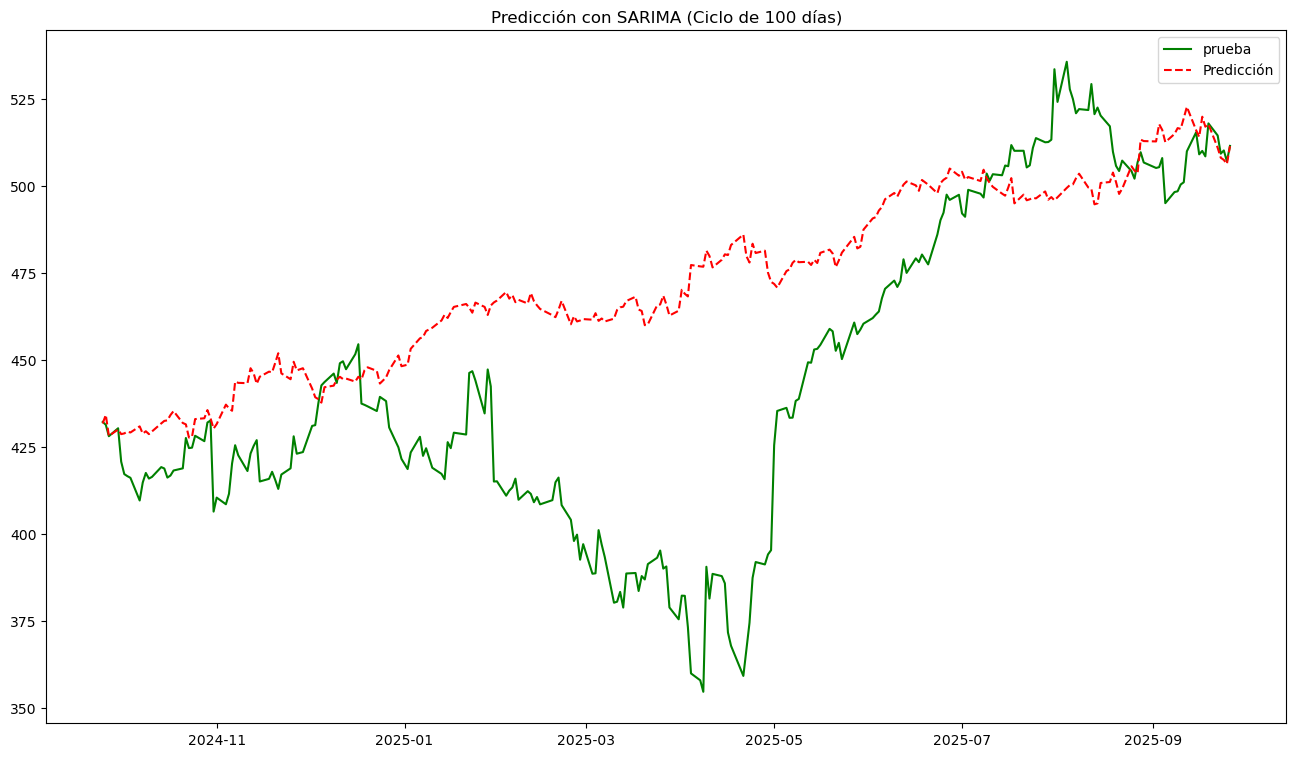

In [15]:
fig,ax=plt.subplots(figsize=(16,9))
#ax.plot(train, label="entrenamiento", color="blue")
ax.plot(test, label='prueba', color='green')
ax.plot(test.index, pred, label="Predicción", color="red", linestyle="dashed")
plt.legend()
plt.title("Predicción con SARIMA (Ciclo de 100 días)")
plt.show()

In [27]:
residuos=modelo_fit.resid
residuos.to_csv('residuos_microsoft(r).csv', index=False)
#Prueba de ljung box
import statsmodels.api as sm
ljung=sm.stats.acorr_ljungbox(residuos, return_df=True)
print(ljung)
if ljung['lb_pvalue'][10]>0.05:
    print('El modelo tiene ruido blanco. Buen modelo')
else:
    print('No hay ruido blanco')

      lb_stat  lb_pvalue
1    0.084325   0.771519
2    0.221311   0.895247
3    1.197547   0.753593
4    1.392999   0.845411
5    1.393783   0.924992
6    5.643550   0.464279
7    6.402894   0.493570
8    6.477267   0.593930
9    9.412425   0.400107
10  11.060851   0.352797
El modelo tiene ruido blanco. Buen modelo


In [17]:
# Realizar la prueba de Jarque-Bera sobre los residuos
jb_stat, jb_p_value = jarque_bera(residuos)

print(f'Estadística de Jarque-Bera: {jb_stat:.3f}')
print(f'Valor p de Jarque-Bera: {jb_p_value}')

# Interpretación de la prueba
if jb_p_value < 0.05:
    print("Rechazamos la hipótesis nula: los residuos no siguen una distribución normal.")
else:
    print("No rechazamos la hipótesis nula: los residuos pueden seguir una distribución normal.")

Estadística de Jarque-Bera: 32.488
Valor p de Jarque-Bera: 8.815587497353358e-08
Rechazamos la hipótesis nula: los residuos no siguen una distribución normal.


In [18]:
from statsmodels.stats.diagnostic import het_arch

# Prueba de heterocedasticidad 
arch_test = het_arch(residuos)
print(f'Estadístico: {arch_test[0]}, Valor p: {arch_test[1]}')
if arch_test[1] < 0.05:
    print("Presencia de heterocedasticidad en los residuos.")
else:
    print("No hay evidencia de heterocedasticidad en los residuos.")

Estadístico: 23.033328483081775, Valor p: 0.01062422366863429
Presencia de heterocedasticidad en los residuos.


## Implementar modelo garch a los residuos

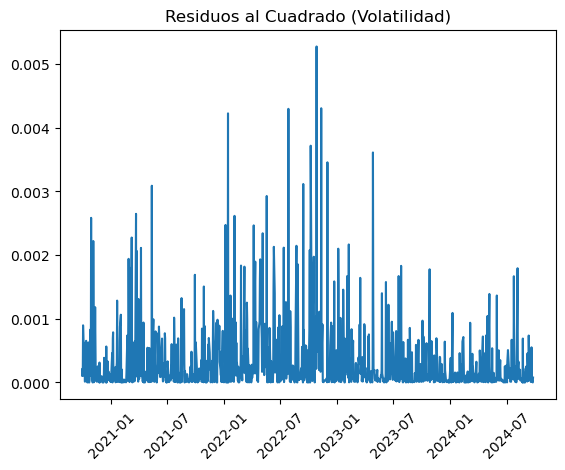

In [19]:
import matplotlib.pyplot as plt
plt.plot(residuos**2)
plt.title("Residuos al Cuadrado (Volatilidad)")
plt.xticks(rotation=45)
plt.show()

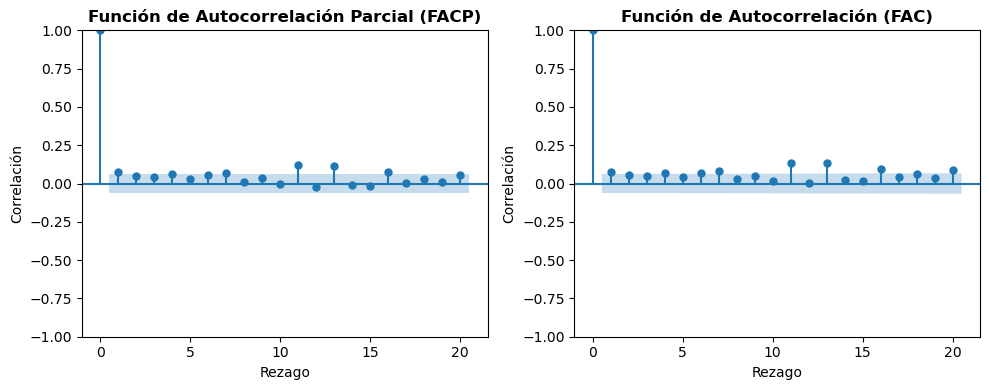

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_pacf(residuos**2, ax=ax[0], lags=20)
plot_acf(residuos**2, ax=ax[1], lags=20)
ax[0].set_title('Función de Autocorrelación Parcial (FACP)', fontsize=12, fontweight='bold')
ax[1].set_title('Función de Autocorrelación (FAC)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Correlación')
ax[1].set_ylabel('Correlación')
ax[0].set_xlabel('Rezago')
ax[1].set_xlabel('Rezago')

plt.tight_layout()
plt.show()

In [21]:
residuos= residuos * 10
from arch import arch_model
arch_modelo=arch_model(residuos, vol='EGARCH',dist="t",p=1,q=1,o=1)
modelo_arch=arch_modelo.fit(disp="off")
print(modelo_arch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:                309.265
Distribution:      Standardized Student's t   AIC:                          -606.529
Method:                  Maximum Likelihood   BIC:                          -577.065
                                              No. Observations:                 1003
Date:                      Tue, Mar 03 2026   Df Residuals:                     1002
Time:                              12:08:41   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

/home2/DSMaster/dcenteno/.local/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03421. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [22]:
# Predicción por simulación Monte Carlo
 ###Generar múltiples escenarios futuros de volatilidad
pred_egarch = modelo_arch.forecast(horizon=n_prueba, method='simulation', simulations=10000)
volatilidad_condicional = np.sqrt(np.mean(pred_egarch.variance.values[-1], axis=0))

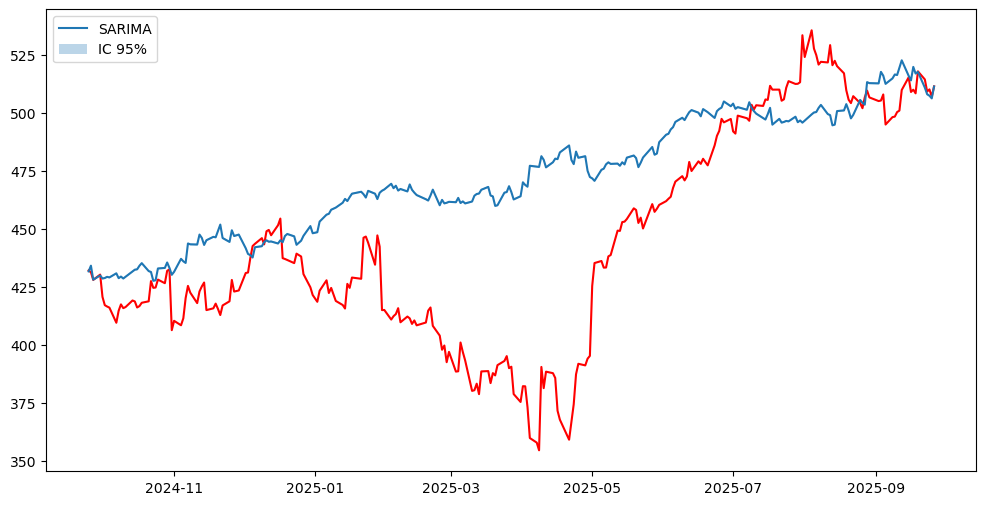

In [23]:
def crear_dataframe_predicciones(pred, volatilidad, test_data, nu, alpha=0.05):
    """
    Crea DataFrame de resultados manejando diferentes dimensiones
    """
    from scipy.stats import t
    # Convertir a arrays numpy
    pred = np.asarray(pred).flatten()
    volatilidad = np.asarray(volatilidad).flatten()
    
    # Calcular multiplicador del intervalo de confianza
    ic_multiplier = t.ppf(1 - alpha/2, nu)
    
    # Determinar el índice apropiado
    if len(pred) == 1:
        index = [test_data.index[0]]
    else:
        index = test_data.index[:len(pred)]
    
    # Crear DataFrame
    resultados = pd.DataFrame({
        'Prediccion': pred,
        'Volatilidad': volatilidad,
        'Inferior': pred - ic_multiplier * volatilidad,
        'Superior': pred + ic_multiplier * volatilidad
    }, index=index)
    
    return resultados

# Usar la función
nu = modelo_arch.params['nu']
resultados = crear_dataframe_predicciones(pred, volatilidad_condicional, test, nu)

plt.figure(figsize=(12, 6))
#plt.plot(train.index, train, color='green')
plt.plot(test.index, test, color='red')
plt.plot(test.index,resultados['Prediccion'], label='SARIMA')
plt.fill_between(test.index,resultados['Inferior'],resultados['Superior'],alpha=0.3,label='IC 95%')
plt.legend()
plt.show()

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Residuos estandarizados (media ajustada por SARIMA, volatilidad por EGARCH)
residuos_estandarizados = residuos / modelo_arch.conditional_volatility

# Test de Ljung-Box (autocorrelación)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuos_estandarizados, lags=[10], return_df=True)
print("Ljung-Box p-valor:", lb_test.iloc[0, 1])  # p > 0.05 indica no autocorrelación
if lb_test.iloc[0, 1]>0.05:
    print('No hay autocorrelacion')
else:
    print('Hay autocorrelacion')

Ljung-Box p-valor: 0.6466381471251985
No hay autocorrelacion


In [25]:
# Test ARCH en residuos estandarizados
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(residuos_estandarizados)
print(f"ARCH Test p-valor: {arch_test[1]}")  # p > 0.05 indica no heterocedasticidad
if arch_test[1]>0.05:
    print('No hay heterocedasticidad')
else:
    print('Hay heterocedasticidad')

ARCH Test p-valor: 0.7004466700877059
No hay heterocedasticidad


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

pred = pd.DataFrame(pred)
pred = pred.set_axis(test.index)

def evaluate_forecast(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # MAE y RMSE del modelo
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAE del modelo ingenuo (naive: y_{t-1})
    naive_forecast = y_true[:-1]   # todo menos el último
    actual_values = y_true[1:]     # todo menos el primero
    mae_naive = mean_absolute_error(actual_values, naive_forecast)
    
    # MASE
    mase = mae / mae_naive if mae_naive != 0 else np.nan
    
    print(f"MAE: {mae:.2f}")
    print(f"MASE: {mase:.2f}")
    print(f"RMSE: {rmse:.2f}")

evaluate_forecast(test, pred)


MAE: 32.39
MASE: 7.45
RMSE: 43.90


https://github.com/narencastellon/Serie-de-tiempo-con-Machine-Learning/blob/main/Modulo%2010.1.Introducció%20a%20Modelos_Arima.ipynb